In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [2]:
img_height,img_width=32,32
batch_size=20

train_ds=tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\beher\OneDrive\Desktop\DeepLearning\cnn\fruits\fruits\train",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\beher\OneDrive\Desktop\DeepLearning\cnn\fruits\fruits\validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

test_data=tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\beher\OneDrive\Desktop\DeepLearning\cnn\fruits\fruits\test",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


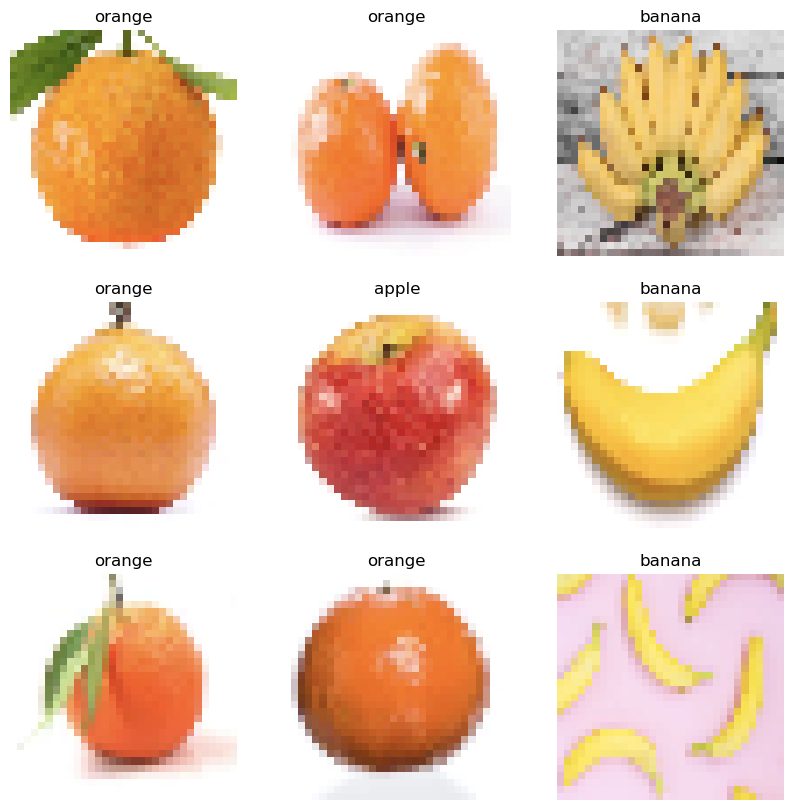

In [3]:
clas_name=['apple','banana','orange']
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(clas_name[labels[i]])
    plt.axis("off")

In [4]:
model=tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32,3,activation='relu'),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(64,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation='softmax'),
        tf.keras.layers.Dense(3)
    ]
)


In [5]:
model.compile(
    optimizer='rmsprop',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [6]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3565 - loss: 1.0982 - val_accuracy: 0.3485 - val_loss: 1.0972
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3717 - loss: 1.0941 - val_accuracy: 0.5303 - val_loss: 1.0725
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4935 - loss: 1.0541 - val_accuracy: 0.5758 - val_loss: 1.0100
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5696 - loss: 0.9989 - val_accuracy: 0.5909 - val_loss: 0.9699
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6022 - loss: 0.9687 - val_accuracy: 0.5000 - val_loss: 0.9726
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6196 - loss: 0.9548 - val_accuracy: 0.6212 - val_loss: 0.9307
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6870 - loss: 0.9351 - val_accuracy: 0.6515 - val_loss: 0.9153
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7435 - loss: 0.9106 - val_accuracy: 0.8333 - v

In [7]:
model.evaluate(test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9385 - loss: 0.6210


[0.6209590435028076, 0.9384615421295166]

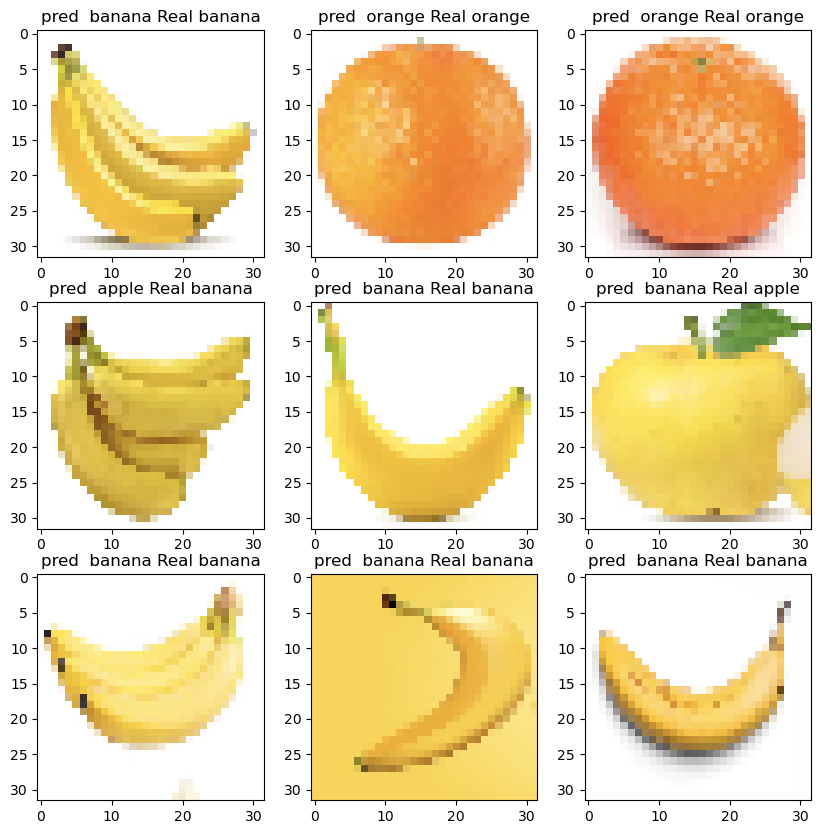

In [8]:
import numpy
plt.figure(figsize=(10, 10))
for images, labels in test_data.take(1):
  classification=model(images)
  for i in range(9):
    ax = plt.subplot(3, 3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index=numpy.argmax(classification[i])
    plt.title("pred  "+clas_name[index] + " Real "+clas_name[labels[i]])
    # plt.axis("off")

In [9]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# Load trained model
# model = tf.keras.models.load_model("fruit_model.keras")

class_names = ["Apple", "Banana", "Orange"]

def predict_fruit(image):
    # Resize to training size
    image = image.resize((32, 32))

    # Convert to RGB
    image = image.convert("RGB")

    # Convert to numpy array
    image = np.array(image).astype("float32")

    # Add batch dimension
    image = np.expand_dims(image, axis=0)

    # Predict
    prediction = model.predict(image, verbose=0)

    # Your model was trained with from_logits=True
    prediction = tf.nn.softmax(prediction)[0].numpy()

    return {
        class_names[0]: float(prediction[0]),
        class_names[1]: float(prediction[1]),
        class_names[2]: float(prediction[2]),
    }


demo = gr.Interface(
    fn=predict_fruit,
    inputs=gr.Image(type="pil", label="Upload Fruit Image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="🍎 Fruit Classification",
    description="Upload an Apple, Banana, or Orange image.",

    examples=[
        ["examples/apple.jpg"],
        ["examples/banana.jpg"],
        ["examples/orange.jpg"]
    ],

    theme="soft"
)

demo.launch()

c:\Users\beher\anaconda3\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
